### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

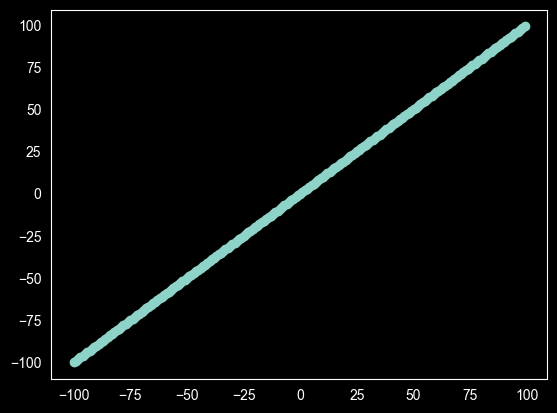

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

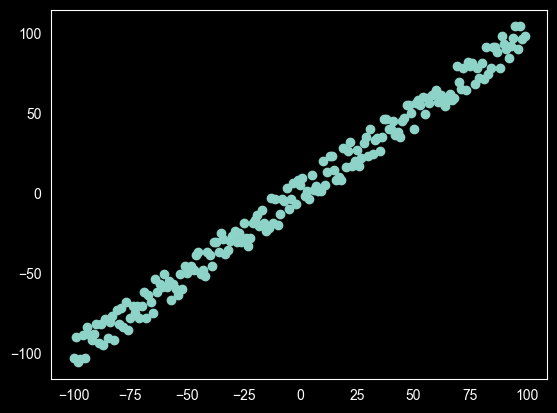

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

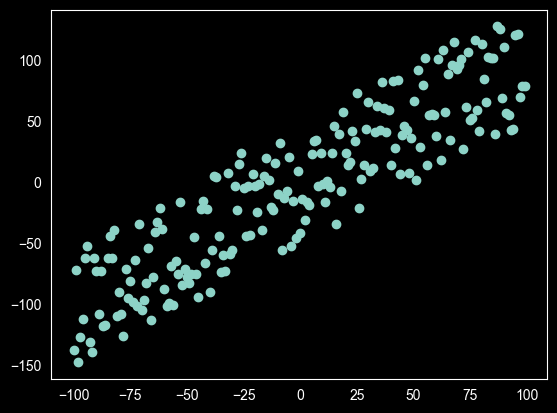

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

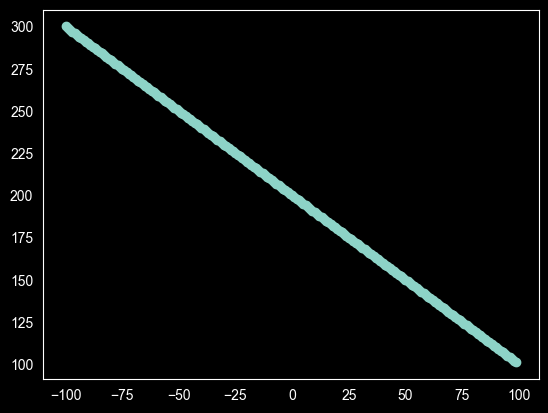

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

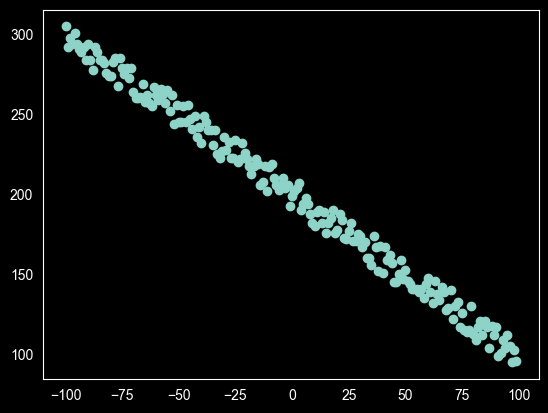

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

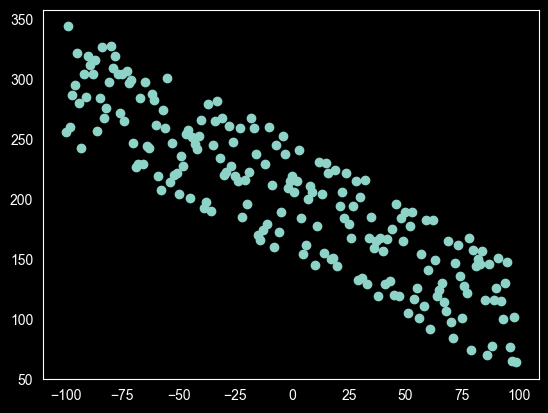

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

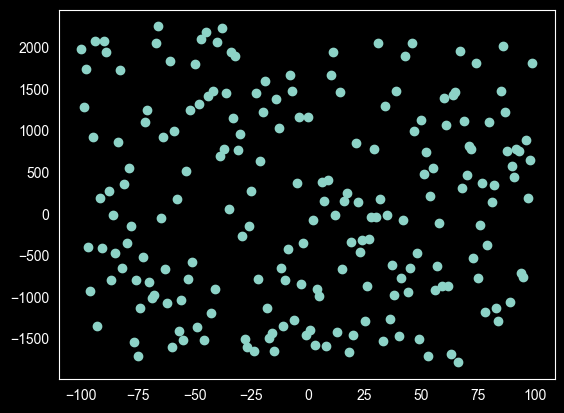

In [8]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Metrics

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    try:
        return round(mse, 4)
    except Exception:
        return mse

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    try:
        return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)
    except Exception:
        return 1 - sum((y-y_pred)**2)/sum((y-y_mean)**2)


### Solve by Normal Equation

In [49]:
# Lasso Has no Closed for Solution in Matrix Form

### Solve by Gradient Descent

In [62]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1, lmbda=1):
    x_scaled = (x - x.mean()) / x.std()
    y_scaled = (y - y.mean()) / y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    n = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / n * x_b.T @ (x_b @ theta - y_scaled)
        lasso_gradient = lmbda * np.sign(theta)
        lasso_gradient[0] = 0 # Don't regularize intercept
        gradients += lasso_gradient
        theta = theta - eta * gradients
    c_scaled = theta[0][0]
    m_scaled = theta[1][0]
    m = m_scaled * y.std() / x.std()
    c = (c_scaled * y.std() + y.mean() - m * x.mean())
    y_pred = predict(x, m, c)
    MSE = round(mse(y, y_pred.reshape(-1, 1))[0], 4)
    R2 = round(r2(y, y_pred.reshape(-1, 1))[0], 4)
    print(f"Slope : {round(m, 4)}"
        f"  y-Intercept : {round(c, 4)}"
        f"  MSE : {MSE}"
        f"  R2 : {R2}")
    plt.scatter(x, y)
    plt.plot(x, [m * i + c for i in x], "r")
    plt.grid()
    plt.show()

Slope : 0.5  y-Intercept : -0.25  MSE : 10733.5625  R2 : -2.2201


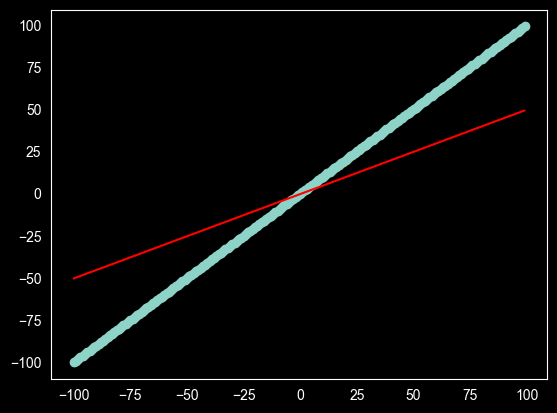

In [63]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

Slope : 0.4949  y-Intercept : -0.4375  MSE : 11284.8008  R2 : -2.3756


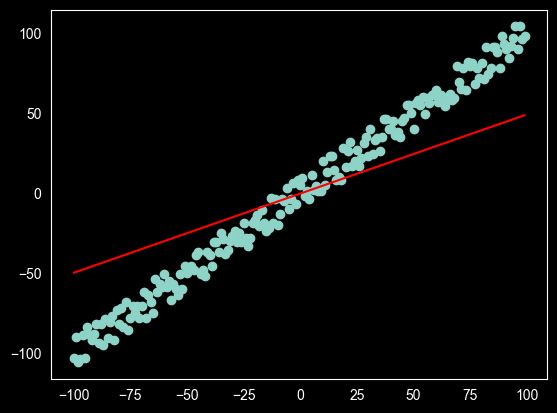

In [64]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

Slope : 0.4654  y-Intercept : -2.5573  MSE : 19003.7937  R2 : -3.2406


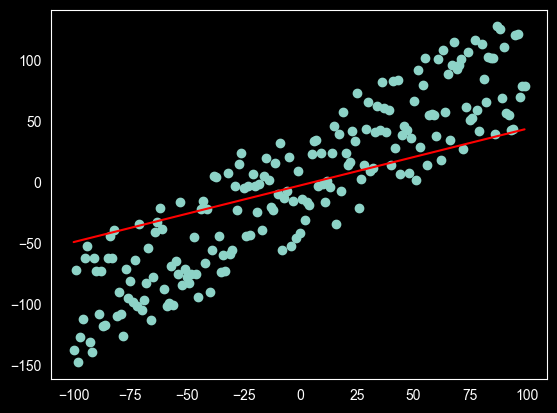

In [65]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

Slope : -0.5  y-Intercept : 200.25  MSE : 10733.5625  R2 : -2.2201


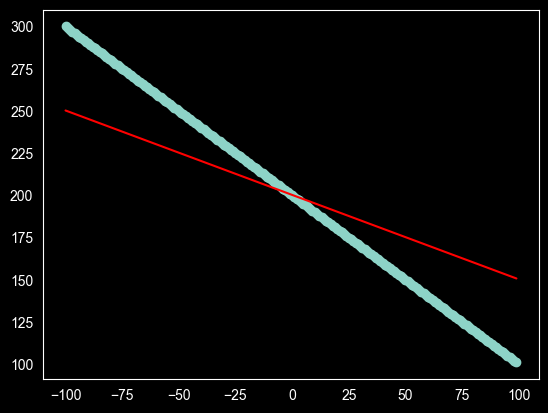

In [66]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

Slope : -0.4998  y-Intercept : 200.0051  MSE : 11804.0856  R2 : -2.4749


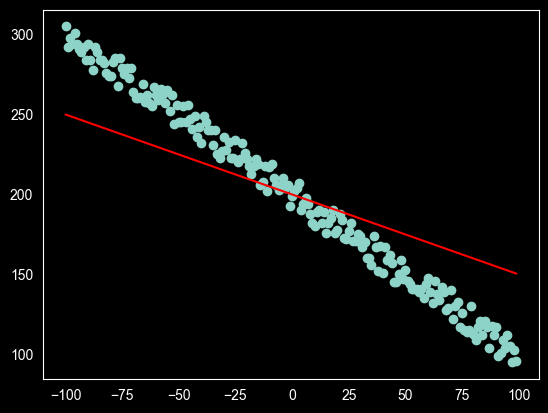

In [67]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

Slope : -0.4345  y-Intercept : 201.9577  MSE : 3526.4161  R2 : 0.1581


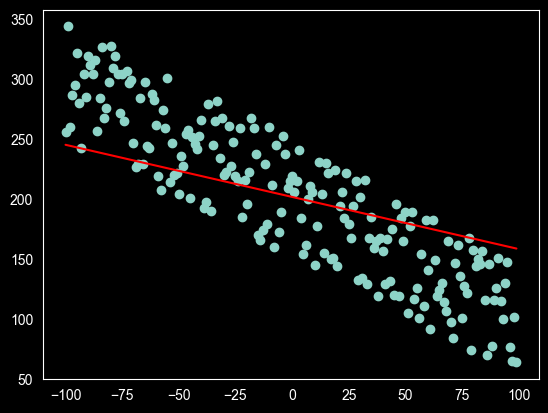

In [68]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

Slope : 0.635  y-Intercept : 124.1425  MSE : 3443018.4497  R2 : -1.5543


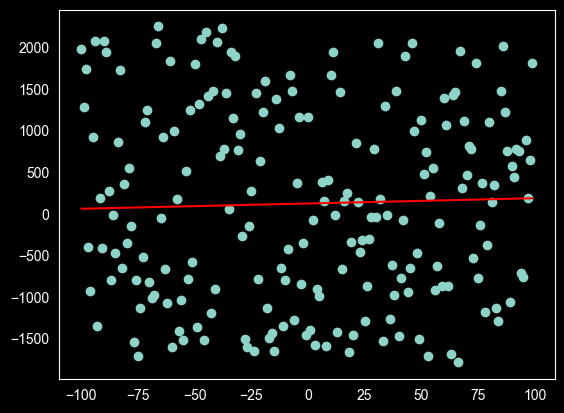

In [69]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [48]:
from sklearn.linear_model import Lasso

def get_model(X, y):
    model = Lasso(alpha=1000)
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()


Slope : [0.6999925]   y-Intercept : -0.15   MSE : 300.0075001875046   R2 : 0.9099954998312444


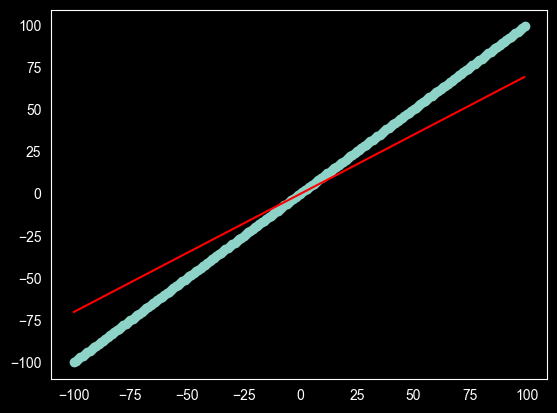

In [51]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

Slope : [0.69563714]   y-Intercept : -0.3372   MSE : 338.74504626490653   R2 : 0.8986708202820531


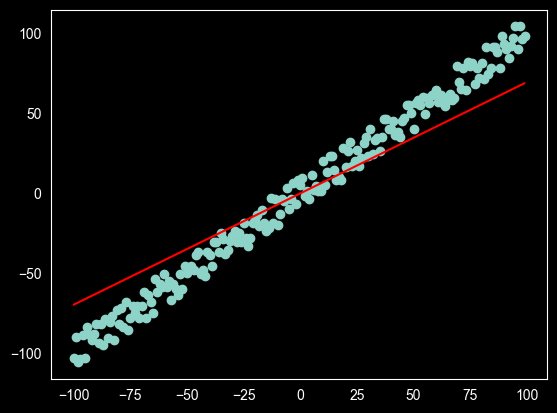

In [52]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

Slope : [0.74517063]   y-Intercept : -2.4174   MSE : 1140.1800256731417   R2 : 0.7455753727478375


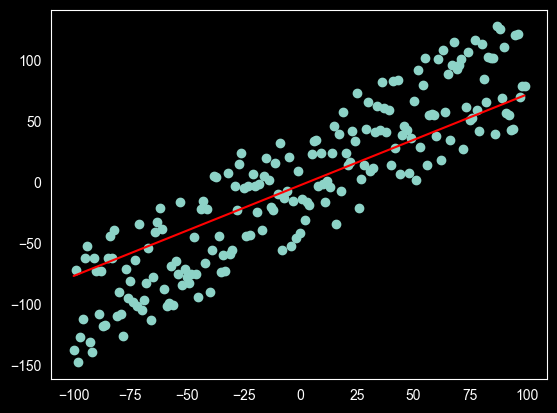

In [53]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

Slope : [-0.6999925]   y-Intercept : 200.15   MSE : 300.0075001875046   R2 : 0.9099954998312444


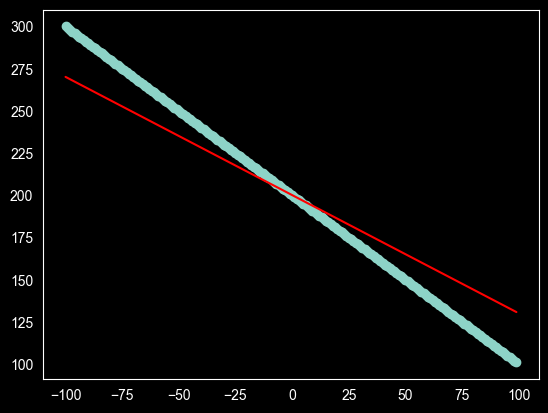

In [54]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

Slope : [-0.70452636]   y-Intercept : 199.9027   MSE : 333.4339571776794   R2 : 0.9018437137709233


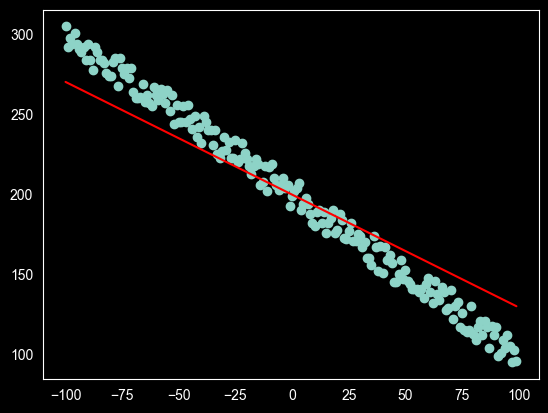

In [55]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

Slope : [-0.69497562]   y-Intercept : 201.8275   MSE : 1188.5629804882622   R2 : 0.716228061286295


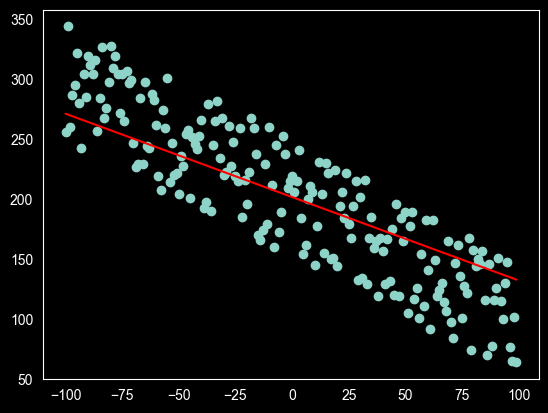

In [56]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

Slope : [-0.1821473]   y-Intercept : 123.7339   MSE : 1347437.0703983086   R2 : 0.0003523108279810394


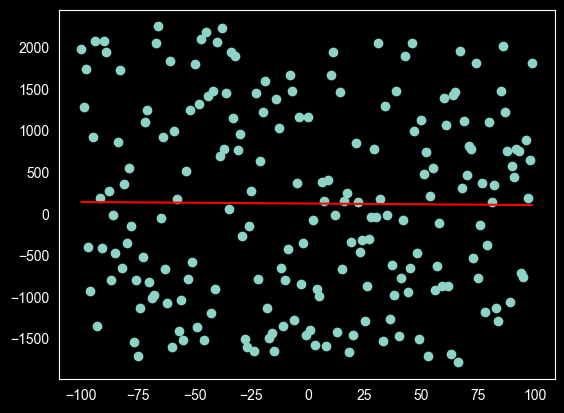

In [57]:
# Solve for Data 7
solve_by_sklearn(x7, y7)